# PyTorch 基础与线性模型

欢迎来到本次实验练习！本实验将带领你系统掌握 **PyTorch** 深度学习框架的核心用法。

**实验目标：**
- 熟悉 `torch.Tensor` 的创建与运算
- 实现基本线性函数、激活函数与参数初始化
- 搭建并训练完整的三层全连接神经网络
- 体验 PyTorch 自动求导（autograd）机制

**数据集：** 手势数字数据集（0–5 六类手势图片）

## 目录
- [1 - 导入依赖包](#1)
    - [1.1 - 查看 PyTorch 版本](#1-1)
- [2 - PyTorch 基础运算](#2)
    - [2.1 - 线性函数](#2-1)
    - [2.2 - Sigmoid 激活函数](#2-2)
    - [2.3 - One-Hot 编码](#2-3)
    - [2.4 - 参数初始化](#2-4)
- [3 - 构建神经网络](#3)
    - [3.1 - 前向传播](#3-1)
    - [3.2 - 计算损失](#3-2)
    - [3.3 - 训练模型](#3-3)
- [4 - 参考资料](#4)

<a name='1'></a>
## 1 - 导入依赖包

In [45]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import time

<a name='1-1'></a>
### 1.1 - 查看 PyTorch 版本

运行下方代码确认当前环境中 PyTorch 的版本号。

In [46]:
print(torch.__version__)

2.2.2


<a name='2'></a>
## 2 - PyTorch 基础运算

PyTorch 的核心数据结构是 `torch.Tensor`，它与 NumPy 的 `ndarray` 类似，
但额外支持 GPU 加速和自动求导。本节通过手势数字数据集来熟悉常用操作。

### 手势数字数据集

数据集包含 **1080 张训练图片**和 **120 张测试图片**，分辨率均为 64×64×3（RGB）。
每张图片对应一个手势数字（0–5），共 6 个类别。

In [47]:
train_file = h5py.File('datasets/train_signs.h5', "r")
test_file  = h5py.File('datasets/test_signs.h5',  "r")

X_train_orig = np.array(train_file['train_set_x'])  # shape: (1080, 64, 64, 3)
Y_train_orig = np.array(train_file['train_set_y'])  # shape: (1080,)
X_test_orig  = np.array(test_file['test_set_x'])    # shape: (120,  64, 64, 3)
Y_test_orig  = np.array(test_file['test_set_y'])    # shape: (120,)

print("X_train shape:", X_train_orig.shape)
print("Y_train shape:", Y_train_orig.shape)
print("X_test  shape:", X_test_orig.shape)
print("Y_test  shape:", Y_test_orig.shape)

X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080,)
X_test  shape: (120, 64, 64, 3)
Y_test  shape: (120,)


In [48]:
print("Unique labels:", np.unique(Y_train_orig))

Unique labels: [0 1 2 3 4 5]


数据集包含六个类别（数字 0–5），每个类别对应一种手势。
下面我们可视化其中 25 张训练样本，直观感受数据分布。

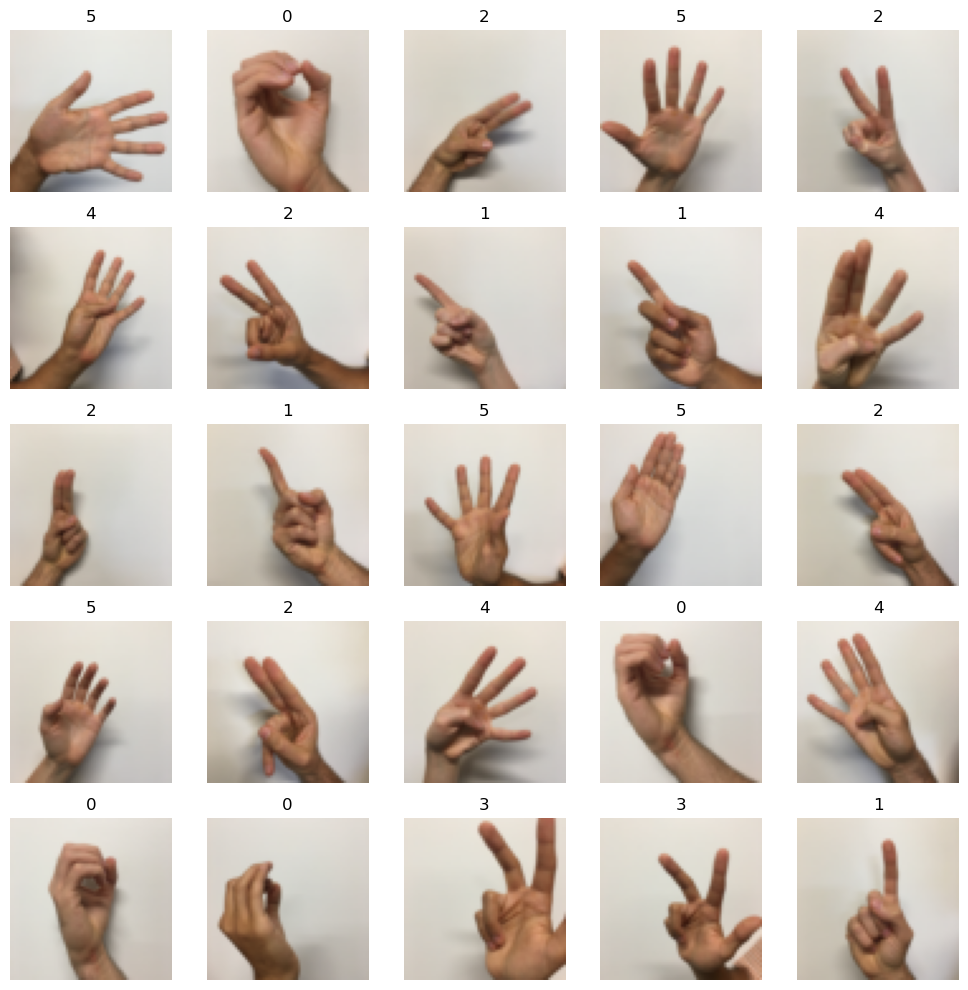

In [49]:
plt.figure(figsize=(10, 10))
for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_orig[i].astype("uint8"))
    plt.title(Y_train_orig[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

### 数据预处理：归一化与展平

每张图片的形状为 `(64, 64, 3)`，像素值范围为 [0, 255]。
我们需要做两步预处理：
1. **展平**：将图片变形为一维向量，长度 = 64 × 64 × 3 = **12288**
2. **归一化**：将像素值除以 255，使其落在 [0, 1] 区间

归一化能加快梯度下降的收敛速度，是深度学习预处理的标准做法。

In [50]:
def normalize(X):
    """
    Flatten and normalise a batch of images.

    Arguments:
    X -- numpy array of shape (N, 64, 64, 3), dtype uint8

    Returns:
    torch.Tensor of shape (N, 12288), dtype float32, values in [0, 1]
    """
    X = X.astype(np.float32) / 255.0
    X = X.reshape(X.shape[0], -1)   # (N, 12288)
    return torch.tensor(X)


X_train = normalize(X_train_orig)                           # (1080, 12288)
X_test  = normalize(X_test_orig)                            # (120,  12288)
Y_train = torch.tensor(Y_train_orig, dtype=torch.long)      # (1080,)
Y_test  = torch.tensor(Y_test_orig,  dtype=torch.long)      # (120,)

print("X_train tensor:", X_train.shape, X_train.dtype)
print("Y_train tensor:", Y_train.shape, Y_train.dtype)
print("First sample:",   X_train[0][:5])   # first 5 values

X_train tensor: torch.Size([1080, 12288]) torch.float32
Y_train tensor: torch.Size([1080]) torch.int64
First sample: tensor([0.8902, 0.8627, 0.8392, 0.8902, 0.8667])


<a name='2-1'></a>
### 2.1 - 线性函数

线性变换 $Y = WX + b$ 是神经网络每一层的基础运算。
在 PyTorch 中，矩阵乘法使用 `torch.matmul(A, B)`（也可写作 `A @ B`），
张量的创建使用 `torch.tensor(data, dtype=...)`。

#### 练习提示

**任务**：构造三个随机张量 X、W、b，并计算线性变换 $Y = WX + b$。

**核心 API**：
- `np.random.randn(rows, cols)` — 生成标准正态分布的 NumPy 数组
- `torch.tensor(array, dtype=torch.float32)` — 从 NumPy 数组创建 PyTorch 张量
- `torch.matmul(W, X)` — 计算矩阵乘积（等价于 `W @ X`）

**维度要求**：
- X 的形状：`(3, 1)`
- W 的形状：`(4, 3)`
- b 的形状：`(4, 1)`
- Y 的形状：`(4, 1)`（$W$ 的行数 × $X$ 的列数）

**注意**：需按照 X → W → b 的顺序创建张量，以确保随机数与测试用例一致。

**思考**：为什么 `W @ X` 的形状是 `(4, 1)` 而不是 `(3, 4)`？矩阵乘法的维度规则是什么？

In [ ]:
# 需要完成的函数: linear_function

def linear_function():
    """
    实现线性变换 Y = WX + b。
        X 的形状：(3, 1)
        W 的形状：(4, 3)
        b 的形状：(4, 1)

    返回:
    Y -- torch.Tensor，形状 (4, 1)
    """
    np.random.seed(1)

    # 按照 X → W → b 的顺序创建张量（约 4 行）
    # X = ...
    # W = ...
    # b = ...
    # Y = ...
    ### START CODE HERE ###
    
    ### END CODE HERE ###
    return Y


In [52]:
result = linear_function()
print(result)

assert isinstance(result, torch.Tensor), "Use the PyTorch API (torch.tensor / torch.matmul)"
assert np.allclose(result.numpy(),
                   [[-2.15657382], [2.95891446], [-1.08926781], [-0.84538042]]), \
    "Wrong values. Check your matrix dimensions and order of creation."
print("\033[92mAll tests passed")

tensor([[-2.1566],
        [ 2.9589],
        [-1.0893],
        [-0.8454]])
All tests passed


**期望输出：**
```
tensor([[-2.1566],
        [ 2.9589],
        [-1.0893],
        [-0.8454]])
```

<a name='2-2'></a>
### 2.2 - Sigmoid 激活函数

Sigmoid 函数将任意实数映射到 (0, 1) 区间，定义为：

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

在 PyTorch 中，`torch.sigmoid(z)` 可以直接对张量中的每个元素计算 sigmoid 值，
且支持标量、向量和矩阵。

#### 练习提示

**任务**：将 Python 数值 `z` 转换为 `float32` 类型的 PyTorch 张量，再计算其 sigmoid 值。

**核心 API**：
- `torch.tensor(value, dtype=torch.float32)` — 将 Python 标量转换为张量
- `torch.sigmoid(z)` — 计算逐元素 sigmoid

**输入/输出**：
- 输入：Python 标量（如 `-1`、`0`、`2`）
- 输出：`torch.float32` 类型的 0 维张量

**常见错误**：若忘记先将 `z` 转换为张量，`torch.sigmoid` 将无法处理 Python 原生数值类型。

**思考**：`torch.sigmoid(z)` 与 `torch.nn.functional.sigmoid(z)` 有什么区别？

In [ ]:
# 需要完成的函数: sigmoid

def sigmoid(z):
    """
    计算 z 的 sigmoid 值。

    参数:
    z -- Python 标量或数值

    返回:
    a -- torch.Tensor（float32），sigmoid(z)
    """
    # 第一步：将 z 转换为 float32 张量
    # 第二步：调用 torch.sigmoid
    # （约 2 行）
    ### START CODE HERE ###
    
    ### END CODE HERE ###
    return a


In [54]:
result = sigmoid(-1)
print("type:           ", type(result))
print("dtype:          ", result.dtype)
print("sigmoid(-1) =   ", result.item())
print("sigmoid(0)  =   ", sigmoid(0.0).item())
print("sigmoid(12) =   ", sigmoid(12).item())


def sigmoid_test(target):
    result = target(0)
    assert isinstance(result, torch.Tensor), "Output must be a torch.Tensor"
    assert result.dtype == torch.float32, "dtype must be float32"
    assert abs(target(0).item()   - 0.5)        < 1e-6, "sigmoid(0) should be 0.5"
    assert abs(target(-1).item()  - 0.26894143) < 1e-5, "sigmoid(-1) should be ~0.2689"
    assert abs(target(12).item()  - 0.9999939)  < 1e-5, "sigmoid(12) should be ~0.9999939"
    print("\033[92mAll tests passed")


sigmoid_test(sigmoid)

type:            <class 'torch.Tensor'>
dtype:           torch.float32
sigmoid(-1) =    0.2689414322376251
sigmoid(0)  =    0.5
sigmoid(12) =    0.9999938011169434
All tests passed


**期望输出：**
```
type:           <class 'torch.Tensor'>
dtype:          torch.float32
sigmoid(-1) =   0.2689414
sigmoid(0)  =   0.5
sigmoid(12) =   0.9999938
```

<a name='2-3'></a>
### 2.3 - One-Hot 编码

在多分类任务中，标签通常以 **类别索引**（整数）存储。
One-Hot 编码将类别索引转换为一个只有对应位置为 1、其余位置为 0 的向量。

例如，当类别总数 C=4 时：
- 类别 0 → `[1, 0, 0, 0]`
- 类别 2 → `[0, 0, 1, 0]`

PyTorch 中使用 `torch.nn.functional.one_hot(label, num_classes)` 实现，
输入标签必须是 `torch.long` 类型（64 位整数）。

#### 练习提示

**任务**：将标签 `label`（可能是整数、列表或张量）转换为形状 `(C,)` 的 float32 One-Hot 向量。

**核心 API**：
- `torch.as_tensor(data, dtype=torch.long)` — 将各种格式数据转为 long 张量
- `.reshape(-1)[0]` — 展平并取第 0 个元素，确保得到 0 维标量张量
- `F.one_hot(tensor, num_classes=C)` — 生成 One-Hot 向量（返回 long 类型）
- `.float()` — 将结果从 long 转为 float32

**维度**：
- 输入：任意形式的单个标签
- 输出：形状 `(C,)` 的 float32 张量

**常见错误**：`F.one_hot` 要求输入是 0 维或 1 维的 long 张量；若传入 float 类型会报错。

**思考**：为什么在 PyTorch 训练时通常不直接使用 One-Hot 编码，而是保留类别索引？

In [ ]:
# 需要完成的函数: one_hot_matrix

def one_hot_matrix(label, C=6):
    """
    计算单个标签的 One-Hot 编码向量。

    参数:
    label -- int、含单个 int 的列表，或 0 维张量
    C     -- int，类别总数

    返回:
    one_hot -- torch.Tensor，形状 (C,)，dtype=float32
    """
    # 第一步：将 label 转为 0 维 long 张量
    # 第二步：调用 F.one_hot 并转为 float32
    # （约 2 行）
    ### START CODE HERE ###
    
    ### END CODE HERE ###
    return one_hot


In [56]:
def one_hot_matrix_test(target):
    # Test 1: scalar int label
    label = 1
    C = 4
    result = target(label, C)
    print("Test 1:", result)
    assert result.shape[0] == C, "Use the parameter C"
    assert np.allclose(result.numpy(), [0., 1., 0., 0.]), "Wrong output – use F.one_hot"

    # Test 2: label as a list
    label_2 = [2]
    C = 5
    result = target(label_2, C)
    print("Test 2:", result)
    assert result.shape[0] == C, "Use the parameter C"
    assert np.allclose(result.numpy(), [0., 0., 1., 0., 0.]), "Wrong output – check reshape"

    print("\033[92mAll tests passed")


one_hot_matrix_test(one_hot_matrix)

Test 1: tensor([0., 1., 0., 0.])
Test 2: tensor([0., 0., 1., 0., 0.])
All tests passed


**期望输出：**
```
Test 1: tensor([0., 1., 0., 0.])
Test 2: tensor([0., 0., 1., 0., 0.])
```

> **说明**：在 PyTorch 训练循环中，标签通常以**类别索引**（`torch.long` 类型）的形式
> 直接传入 `F.cross_entropy`，该函数内部已包含 Softmax 和 One-Hot 的计算，
> 无需手动执行 One-Hot 转换。

In [57]:
# Visualise the one-hot encoding for the first 5 training labels
print("First 5 labels:", Y_train[:5].tolist())
for label in Y_train[:5]:
    print(label.item(), "->", one_hot_matrix(label.item()).numpy())

First 5 labels: [5, 0, 2, 5, 2]
5 -> [0. 0. 0. 0. 0. 1.]
0 -> [1. 0. 0. 0. 0. 0.]
2 -> [0. 0. 1. 0. 0. 0.]
5 -> [0. 0. 0. 0. 0. 1.]
2 -> [0. 0. 1. 0. 0. 0.]


<a name='2-4'></a>
### 2.4 - 参数初始化

权重参数的初始化对神经网络的训练至关重要。
若将所有权重初始化为零，所有神经元将输出相同的值，导致对称性问题。

**Xavier（Glorot）正态初始化**：根据前后层的神经元数量来缩放初始权重的方差，
是全连接网络中最常用的初始化策略之一。

在 PyTorch 中使用 `nn.Parameter` 包装张量，使优化器能自动追踪并更新该参数。

**网络结构**：
$$\underbrace{12288}_{输入} \rightarrow \underbrace{25}_{隐藏层1} \rightarrow \underbrace{12}_{隐藏层2} \rightarrow \underbrace{6}_{输出}$$

#### 练习提示

**任务**：使用 Xavier 正态分布初始化权重，使用零向量初始化偏置，并用 `nn.Parameter` 包装。

**核心 API**：
- `torch.empty(rows, cols)` — 创建未初始化的空张量
- `nn.init.xavier_normal_(tensor)` — 原地（in-place）应用 Xavier 正态初始化
- `torch.zeros(rows, cols)` — 创建全零张量（用于偏置）
- `nn.Parameter(tensor)` — 将张量标记为可训练参数

**各参数形状**：
| 参数 | 形状 |
|------|------|
| W1   | (25, 12288) |
| b1   | (25, 1) |
| W2   | (12, 25) |
| b2   | (12, 1) |
| W3   | (6, 12) |
| b3   | (6, 1) |

**常见错误**：
- 形状写反（如把 `(25, 12288)` 写成 `(12288, 25)`）
- 忘记用 `nn.Parameter` 包装，导致优化器无法更新该参数

**思考**：为什么偏置 b 通常初始化为零而不是随机值？

In [ ]:
# 需要完成的函数: initialize_parameters

def initialize_parameters():
    """
    使用 Xavier 正态分布初始化三层全连接网络的参数。
    各参数形状：
        W1: (25, 12288)   b1: (25, 1)
        W2: (12, 25)      b2: (12, 1)
        W3: (6,  12)      b3: (6,  1)

    返回:
    parameters -- 字典，键为 W1, b1, W2, b2, W3, b3（均为 nn.Parameter）
    """
    torch.manual_seed(1)

    # 初始化权重（Xavier 正态）和偏置（全零）
    # （约 6 行）
    ### START CODE HERE ###
    
    ### END CODE HERE ###

    parameters = {"W1": W1, "b1": b1,
                  "W2": W2, "b2": b2,
                  "W3": W3, "b3": b3}
    return parameters


In [59]:
def initialize_parameters_test(target):
    params = target()

    expected_shapes = {
        "W1": (25, 12288), "b1": (25, 1),
        "W2": (12, 25),    "b2": (12, 1),
        "W3": (6,  12),    "b3": (6,  1),
    }

    for key, shape in expected_shapes.items():
        print(f"{key} shape: {tuple(params[key].shape)}")
        assert isinstance(params[key], nn.Parameter), \
            f"{key} must be nn.Parameter – use nn.Parameter(torch.empty(...))"
        assert tuple(params[key].shape) == shape, \
            f"{key}: wrong shape. Expected {shape}, got {tuple(params[key].shape)}"

    # Weight matrices should be Xavier-initialised (near-zero mean, reasonable std)
    for key in ["W1", "W2", "W3"]:
        data = params[key].detach()
        assert abs(data.mean().item()) < 0.2, \
            f"{key}: mean too large – use nn.init.xavier_normal_"
        assert 0 < data.std().item() < 1, \
            f"{key}: std out of range – use nn.init.xavier_normal_"

    # Biases should be zero
    for key in ["b1", "b2", "b3"]:
        assert params[key].detach().abs().max().item() == 0, \
            f"{key}: biases should be initialised to 0"

    print("\033[92mAll tests passed")


initialize_parameters_test(initialize_parameters)

W1 shape: (25, 12288)
b1 shape: (25, 1)
W2 shape: (12, 25)
b2 shape: (12, 1)
W3 shape: (6, 12)
b3 shape: (6, 1)
All tests passed


**期望输出：**
```
W1 shape: (25, 12288)
b1 shape: (25, 1)
W2 shape: (12, 25)
b2 shape: (12, 1)
W3 shape: (6, 12)
b3 shape: (6, 1)
```

In [60]:
parameters = initialize_parameters()

<a name='3'></a>
## 3 - 构建第一个 PyTorch 神经网络

本节将把前面实现的模块组合起来，搭建一个完整的三层全连接分类网络：

$$X \xrightarrow{W1, b1} Z_1 \xrightarrow{\text{ReLU}} A_1 \xrightarrow{W2, b2} Z_2 \xrightarrow{\text{ReLU}} A_2 \xrightarrow{W3, b3} Z_3 \xrightarrow{\text{Softmax}} \hat{y}$$

PyTorch 的自动求导（autograd）机制会在调用 `.backward()` 时自动计算梯度，
无需手动推导反向传播公式。

<a name='3-1'></a>
### 3.1 - 前向传播

前向传播按顺序计算每一层的线性输出和激活值：

$$Z_1 = W_1 X + b_1, \quad A_1 = \text{ReLU}(Z_1)$$
$$Z_2 = W_2 A_1 + b_2, \quad A_2 = \text{ReLU}(Z_2)$$
$$Z_3 = W_3 A_2 + b_3$$

最后一层不加激活函数，直接输出 logits $Z_3$，由损失函数内部进行 Softmax 归一化。

#### 练习提示

**任务**：按照 LINEAR → ReLU → LINEAR → ReLU → LINEAR 的顺序实现前向传播，返回 $Z_3$。

**核心 API**：
- `torch.matmul(W, X)` 或 `W @ X` — 矩阵乘法
- `F.relu(z)` — ReLU 激活函数，将负值置零

**数据流维度**（以 N 个样本为例）：
| 张量 | 形状 |
|------|------|
| X    | (12288, N) |
| Z1, A1 | (25, N) |
| Z2, A2 | (12, N) |
| Z3   | (6, N) |

**常见错误**：
- 矩阵乘法顺序写反（W 在前，X 或 A 在后）
- 最后一层 Z3 加了激活函数（不应该加）

**思考**：为什么隐藏层要使用 ReLU 而不是线性激活？

In [ ]:
# 需要完成的函数: forward_propagation

def forward_propagation(X, parameters):
    """
    实现前向传播：LINEAR -> ReLU -> LINEAR -> ReLU -> LINEAR

    参数:
    X          -- 输入张量，形状 (12288, N)
    parameters -- 字典，包含 W1, b1, W2, b2, W3, b3

    返回:
    Z3 -- 输出 logits，形状 (6, N)
    """
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    W3, b3 = parameters['W3'], parameters['b3']

    # 按顺序计算 Z1, A1, Z2, A2, Z3（约 5 行）
    # 对应 NumPy 写法：
    # Z1 = W1 @ X + b1
    # A1 = relu(Z1)
    # ...
    ### START CODE HERE ###
    
    ### END CODE HERE ###

    return Z3


In [62]:
def forward_propagation_test(target, X_sample):
    params = initialize_parameters()
    X = X_sample[:2].T   # (12288, 2)

    Z3 = target(X, params)
    print("Z3:\n", Z3)

    assert isinstance(Z3, torch.Tensor), "Output must be a torch.Tensor"
    assert Z3.shape == (6, 2), \
        f"Shape should be (6, N). Got {tuple(Z3.shape)}"

    # Verify gradients flow back through all parameters
    fake_cost = (Z3 - torch.ones(6, 2)).mean()
    fake_cost.backward()
    for key in params:
        assert params[key].grad is not None, \
            f"Gradient for {key} is None – avoid creating new tensors inside forward_propagation"

    print("\033[92mAll tests passed")


forward_propagation_test(forward_propagation, X_train)

Z3:
 tensor([[ 0.9711,  0.7954],
        [ 0.4635,  0.4139],
        [ 0.3084,  0.4427],
        [ 0.0350, -0.0369],
        [ 0.2098,  0.2114],
        [ 0.2630,  0.0778]], grad_fn=<AddBackward0>)
All tests passed


**期望行为**：`Z3` 的形状为 `(6, 2)`，且在调用 `.backward()` 后 `W1.grad` 不为 `None`。

<a name='3-2'></a>
### 3.2 - 计算损失

多分类任务通常使用**分类交叉熵**作为损失函数：

$$\mathcal{L} = -\sum_{i=1}^{N} \log \hat{p}_{y_i}$$

其中 $\hat{p}_{y_i}$ 是模型对样本 $i$ 的真实类别的预测概率。

PyTorch 的 `F.cross_entropy(input, target)` 已将 Softmax 和交叉熵合并：
- `input` 的形状为 `(N, C)`（N 个样本，C 个类别的 logits）
- `target` 的形状为 `(N,)`，每个元素是对应样本的类别索引（`torch.long`）
- `reduction='sum'` 表示对所有样本的损失求和（而非平均）

#### 练习提示

**任务**：使用 `F.cross_entropy` 计算所有样本损失之和。

**核心 API**：
- `F.cross_entropy(input, target, reduction='sum')` — 计算带 Softmax 的交叉熵损失
  - `input` 形状：`(N, C)` — 需将 logits 从 `(C, N)` 转置为 `(N, C)`
  - `target` 形状：`(N,)` — 类别索引，`torch.long` 类型

**注意**：
- `logits` 的形状是 `(C, N) = (6, N)`，而 `F.cross_entropy` 期望 `(N, C)`，
  因此需要转置：`logits.T`
- `reduction='sum'` 而不是默认的 `'mean'`，这样总损失会随样本数增加

**思考**：损失使用 `sum` 还是 `mean` 会影响学习率的选择吗？为什么？

In [ ]:
# 需要完成的函数: compute_total_loss

def compute_total_loss(logits, labels):
    """
    计算分类交叉熵的总损失（所有样本损失之和）。

    参数:
    logits -- torch.Tensor，形状 (6, N)，前向传播的原始输出
    labels -- torch.Tensor，形状 (N,)，dtype=torch.long，类别索引

    返回:
    total_loss -- 标量 torch.Tensor
    """
    # 提示：使用 F.cross_entropy，将 logits 转置并设置 reduction='sum'
    # （约 1 行）
    ### START CODE HERE ###
    
    ### END CODE HERE ###
    return total_loss


In [64]:
def compute_total_loss_test(target):
    # logits of shape (6, 2)
    logits = torch.tensor([[ 2.4048107,   5.0334096],
                            [-0.7921977,  -4.1523376],
                            [ 0.9447198,  -0.46802214],
                            [ 1.158121,    3.9810789],
                            [ 4.768706,    2.3220146],
                            [ 6.1481323,   3.909829]])

    # --- Test 1: use the first two training labels ---
    labels = Y_train[:2]   # shape (2,), long
    result = target(logits, labels)
    print("Test 1:", result)
    assert isinstance(result, torch.Tensor), "Use the PyTorch API"
    assert result.item() > 0, "Loss should be positive"
    # Verify against direct F.cross_entropy
    expected = F.cross_entropy(logits.T, labels, reduction='sum')
    assert torch.allclose(result, expected), \
        "Result doesn't match F.cross_entropy(..., reduction='sum')"

    # --- Test 2: known values ---
    logits2 = torch.tensor([[1., 0., 0.],
                             [1., 0., 0.],
                             [1., 0., 0.]]).T   # shape (3, 3), each column is one sample
    labels2 = torch.tensor([0, 1, 2], dtype=torch.long)
    result2 = target(logits2, labels2)
    print("Test 2:", result2)
    assert torch.allclose(result2,
                          torch.tensor(3.6543)),\
        "Test 2 does not match. Expected ~3.2958"

    print("\033[92mAll tests passed")


compute_total_loss_test(compute_total_loss)

Test 1: tensor(0.8103)
Test 2: tensor(3.6543)
All tests passed


**期望输出：**
```
Test 2: tensor(3.2958)
```

<a name='3-3'></a>
### 3.3 - 训练模型

PyTorch 的训练循环通常包含以下步骤：
1. `optimizer.zero_grad()` — 清零上一步的梯度
2. 前向传播：计算 logits 和损失
3. `loss.backward()` — 反向传播，自动计算梯度
4. `optimizer.step()` — 优化器根据梯度更新参数

本实验使用 **Adam 优化器**（Adaptive Moment Estimation），
它结合了动量和自适应学习率的优点，是深度学习中最常用的优化算法之一。

下方 `model()` 函数已为你实现完整的训练循环，只需完成练习 1–6 后运行即可。

In [65]:
def model(X_train, Y_train, X_test, Y_test,
          learning_rate=0.0001, num_epochs=1500,
          minibatch_size=32, print_cost=True):
    """
    训练三层全连接神经网络：LINEAR → ReLU → LINEAR → ReLU → LINEAR → Softmax。

    参数:
    X_train        -- (1080, 12288) 的 float32 张量
    Y_train        -- (1080,) 的 long 类型类别索引
    X_test         -- (120,  12288) 的 float32 张量
    Y_test         -- (120,) 的 long 类型类别索引
    learning_rate  -- Adam 优化器学习率
    num_epochs     -- 训练总轮数
    minibatch_size -- 小批量大小
    print_cost     -- 若为 True，每 10 轮打印一次损失和准确率

    返回:
    parameters    -- 训练后的参数字典
    costs         -- 每 10 轮记录一次的损失列表
    train_acc_log -- 每 10 轮记录一次的训练准确率列表
    test_acc_log  -- 每 10 轮记录一次的测试准确率列表
    """
    costs, train_acc_log, test_acc_log = [], [], []

    # ── 初始化参数 ──
    parameters = initialize_parameters()
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    W3, b3 = parameters['W3'], parameters['b3']

    # ── 配置 Adam 优化器 ──
    optimizer = torch.optim.Adam(
        [W1, b1, W2, b2, W3, b3], lr=learning_rate)

    m = X_train.shape[0]   # 训练样本总数

    # ── 构建数据加载器 ──
    train_loader = DataLoader(
        TensorDataset(X_train, Y_train),
        batch_size=minibatch_size, shuffle=True)
    test_loader  = DataLoader(
        TensorDataset(X_test, Y_test),
        batch_size=minibatch_size)

    # ── 训练循环 ──
    for epoch in range(num_epochs):
        epoch_total_loss = 0.0
        train_correct    = 0

        for minibatch_X, minibatch_Y in train_loader:
            optimizer.zero_grad()   # 清零梯度

            # 前向传播（输入需转置为 (特征数, 样本数)）
            Z3 = forward_propagation(minibatch_X.T, parameters)  # (6, N)

            # 计算总损失
            loss = compute_total_loss(Z3, minibatch_Y)

            # 反向传播与参数更新
            loss.backward()
            optimizer.step()

            epoch_total_loss += loss.item()
            preds = torch.argmax(Z3, dim=0)           # (N,)
            train_correct += (preds == minibatch_Y).sum().item()

        epoch_cost      = epoch_total_loss / m
        epoch_train_acc = train_correct    / m

        if print_cost and epoch % 10 == 0:
            # 在测试集上评估
            test_correct = 0
            with torch.no_grad():
                for mb_X, mb_Y in test_loader:
                    Z3_test = forward_propagation(mb_X.T, parameters)
                    preds   = torch.argmax(Z3_test, dim=0)
                    test_correct += (preds == mb_Y).sum().item()
            epoch_test_acc = test_correct / X_test.shape[0]

            print(f"第 {epoch} 轮损失：{epoch_cost:.6f}")
            print(f"  训练准确率：{epoch_train_acc:.4f}")
            print(f"  测试准确率：{epoch_test_acc:.4f}")

            costs.append(epoch_cost)
            train_acc_log.append(epoch_train_acc)
            test_acc_log.append(epoch_test_acc)

    return parameters, costs, train_acc_log, test_acc_log


In [66]:
parameters, costs, train_acc, test_acc = model(
    X_train, Y_train, X_test, Y_test, num_epochs=1000)

第 0 轮损失：1.818609
  训练准确率：0.1750
  测试准确率：0.1667
第 10 轮损失：1.727285
  训练准确率：0.2519
  测试准确率：0.2833
第 20 轮损失：1.620406
  训练准确率：0.3407
  测试准确率：0.3167
第 30 轮损失：1.520512
  训练准确率：0.3741
  测试准确率：0.4083
第 40 轮损失：1.459149
  训练准确率：0.4120
  测试准确率：0.3833
第 50 轮损失：1.395010
  训练准确率：0.4630
  测试准确率：0.4167
第 60 轮损失：1.339245
  训练准确率：0.5157
  测试准确率：0.5167
第 70 轮损失：1.299699
  训练准确率：0.5389
  测试准确率：0.5000
第 80 轮损失：1.231214
  训练准确率：0.5750
  测试准确率：0.5500
第 90 轮损失：1.186027
  训练准确率：0.6083
  测试准确率：0.5583
第 100 轮损失：1.150438
  训练准确率：0.6009
  测试准确率：0.5750
第 110 轮损失：1.104430
  训练准确率：0.6194
  测试准确率：0.5750
第 120 轮损失：1.064963
  训练准确率：0.6157
  测试准确率：0.5750
第 130 轮损失：1.030424
  训练准确率：0.6361
  测试准确率：0.5000
第 140 轮损失：1.006459
  训练准确率：0.6361
  测试准确率：0.6000
第 150 轮损失：0.975757
  训练准确率：0.6648
  测试准确率：0.5917
第 160 轮损失：0.941174
  训练准确率：0.6639
  测试准确率：0.6333
第 170 轮损失：0.934596
  训练准确率：0.6426
  测试准确率：0.5750
第 180 轮损失：0.893691
  训练准确率：0.6796
  测试准确率：0.6417
第 190 轮损失：0.875427
  训练准确率：0.6889
  测试准确率：0.6417
第 200 轮损失：0.858970
  训练准确率：0.68

**期望输出（近似值，每次运行可能略有差异）：**
```
第 0 轮损失：1.83...
  训练准确率：0.17...
  测试准确率：0.17...
...
第 990 轮损失：0.05...
  训练准确率：0.98...
  测试准确率：0.75...
```

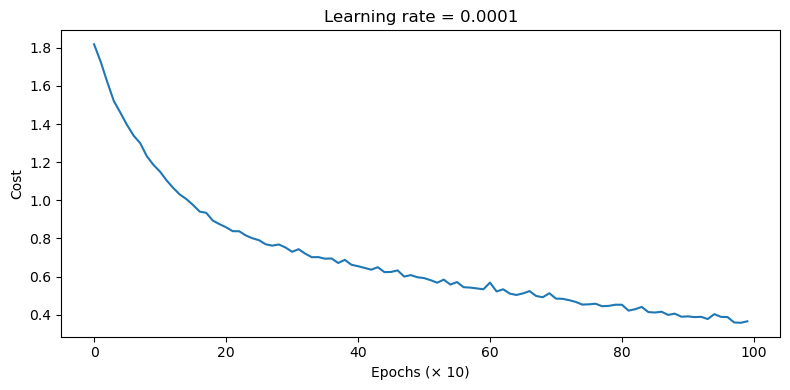

In [67]:
plt.figure(figsize=(8, 4))
plt.plot(np.squeeze(costs))
plt.ylabel('Cost')
plt.xlabel('Epochs (× 10)')
plt.title(f'Learning rate = {0.0001}')
plt.tight_layout()
plt.show()

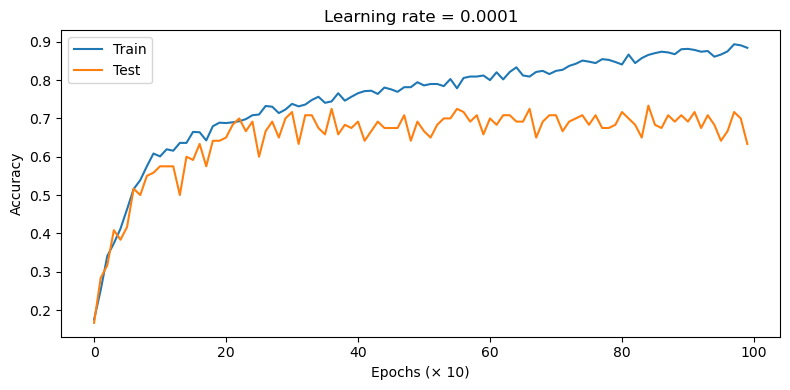

In [68]:
plt.figure(figsize=(8, 4))
plt.plot(np.squeeze(train_acc), label='Train')
plt.plot(np.squeeze(test_acc),  label='Test')
plt.ylabel('Accuracy')
plt.xlabel('Epochs (× 10)')
plt.title(f'Learning rate = {0.0001}')
plt.legend()
plt.tight_layout()
plt.show()

**🎉 恭喜完成本次实验！**

你已经成功使用 PyTorch 构建了完整的深度学习流水线：

- 使用 `torch.Tensor` 和 `nn.Parameter` 管理模型参数
- 实现了线性函数、Sigmoid 激活和 One-Hot 编码
- 使用 Xavier 初始化构建了三层全连接网络
- 通过 autograd 自动完成反向传播
- 使用 Adam 优化器训练网络，在手势数字识别任务上取得了良好效果

**进一步探索：**
- 尝试调整 `learning_rate`、`num_epochs` 或网络结构，观察对精度的影响
- 使用 `nn.Module` 将网络封装为更 Pythonic 的类
- 尝试加入 Dropout 或 BatchNorm 等正则化技术

<a name='4'></a>
## 4 - 参考资料

- PyTorch autograd 机制：https://pytorch.org/docs/stable/notes/autograd.html
- `torch.nn.functional`：https://pytorch.org/docs/stable/nn.functional.html
- Xavier 初始化原理：Glorot & Bengio (2010), *Understanding the difficulty of training deep feedforward neural networks*
- Adam 优化算法：Kingma & Ba (2014), *Adam: A Method for Stochastic Optimization*